Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. Никто вас не ограничивает в наведении красоты, но требуется выполнение того, что в задании.
***

Цель этой домашней работы все еще не научиться делать классные модели, а **подготавливать данные так, чтобы самая простая модель работала хорошо**.

В этом задании поговорим про работу с фичами, использовать можно только то, что указано в задании. НЕЛЬЗЯ МЕНЯТЬ ПАРАМЕТРЫ МОДЕЛЕЙ, нужно их использовать так, как они заданы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import accuracy_score

from typing import List, Dict

# Подготовка данных (1 pt)

## Теория

В этом задании мы уже не будем говорить о подготовке данных, как о проверке данных датасета на пропуски, выбросы и т.д. — вы уже это умеете. Тут мы поговорим о подготовке данных как о их **структуризации для обучения модели**, о **разбиении данных**.

**Три выборки — Train, Valid, Test**

Зачем нужно именно три выборки, а не две? Иногда действительно достаточно разбить данные просто на _train_ и _test_. Но этого может быть недостаточно для серьёзной работы. У каждой из трех выборок есть весьма логичная функция, которая важна для обучени:
* **train** выборка — это те данные, которая видит наша модель и на которой подбираются нужные коэффициенты и веса (функция — буквально **обучение**);
* **valid** выборка — это ваша «внутренняя» проверка, на которой вы в процессе обучения проверяете модель и настраиваете гиперпараметры (функция — **настройка** модели и **валидация**);
* **test** выборка же нужна только для итоговой финальной проверки, вы ее используете один раз в конце (функция — **объективная оценка качества**).

Очевидно (как мы и говорили в прошлой дз), что с test выборкой нельзя делать никаких обработок, связанных с обучением. Если вы хотя бы раз посмотрите на test-данные в процессе настройки модели, вы неосознанно начнёте подстраиваться под них. Это называется **data leakage** (утечка данных). Модель покажет отличные результаты на test, но провалится в реальном применении.

Логичным разбиением для теста можно считать взятие **последних данных**, если они **временные**, или использование **случайного подмножества** всех данных ([`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)). 

***

Еще одно важное для нас в этой работе понятие — это **data drift**.

**Что такое Data Drift?**

Data Drift — это **изменение статистических свойств** данных между выборками (например, между train и valid). Представьте, что вы обучили модель предсказывать стоимость страховки на данных 2020 года. А в 2024 году цены выросли, демография изменилась, появились новые факторы риска. **Распределение данных изменилось** — это и есть _data drift_.

Если очень хочется, то можно выделить несколько видов дрифта:
* **Covariate Drift** — меняется распределение признаков;
* **Label Drift** — меняется распределение целевой переменной;
* **Concept Drift** — меняется связь между признаками.

Третий тип сложно обсуждать без реального наблюдения таких данных, поэтому мы будем трогать только первые два.  
В этом задании мы будем стараться не допустить (отследить) _data drift_ на всех выборках. 

**Для обнаружения дрифта можно использовать определенные [метрики](https://habr.com/ru/companies/plarium/articles/515178/)**

**PSI (Population Stability Index)**

**PSI** — это метрика, которая показывает, насколько изменилось распределение признака между двумя выборками.  
Для расчета данные разбиваются на группы (бины), и для каждого бина сравниваются доли объектов в обучающей (_Expected_) и текущей (_Actual_) выборках по формуле:

$$PSI = \sum_{i=1}^{n} \left( (\% \text{Actual}_i - \% \text{Expected}_i) \cdot \ln\left( \frac{\% \text{Actual}_i}{\% \text{Expected}_i} \right) \right)$$

> Индекс PSI < 0,1 — без изменений.  
> Индекс PSI >= 0,1, но меньше 0,2 — требуются небольшие изменения.  
> PSI >= 0,2 — требуются значительные изменения.

**CSI (Characteristic Stability Index)**

**CSI** — это PSI, рассчитанный для категориальных признаков. Принцип тот же, но вместо квантильных бинов мы используем естественные категории. 

***

Помимо таких метрик можно использовать **статистические тесты** для проверки гипотез.

**KS-тест ([Kolmogorov-Smirnov](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ks_2samp.html))**

KS-тест отвечает на вопрос: «Можно ли считать, что две выборки взяты из одного распределения?»

> $H_0$ (нулевая гипотеза): Распределения одинаковы (drift нет)  
> $H_1$ (альтернативная гипотеза): Распределения различаются (drift есть)

_Правило принятия решения_  
p-value $<$ 0.05: Отклоняем, но есть статистически значимый drift.  
p-value $\geqslant$ 0.05: Не отклоняем, но drift не обнаружен.

**t-тест [Стьюдента](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)**

Используется для сравнения средних значений между двумя выборками.
Лучше применять, когда признак распределён нормально (или выборка большая).

> $H_0$: Средние равны $(\mu_1 = \mu_2)$  
> $H_1$: Средние не равны $(\mu_1 \neq \mu_2)$

ПОДРОБНЕЕ НА МАТСТАТЕ
***

Еще одной классной фишкой для разбиения данных является **K-fold**. это стратегия обучения, которая очень полезна для малого количества данных. Так как это уже скорее отночится именно к стратегиям обучения, то мы не будем ее изучать, но ссылки на [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html),
[еще документацию](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html)
и [текст](https://neerc.ifmo.ru/wiki/index.php?title=%D0%9A%D1%80%D0%BE%D1%81%D1%81-%D0%B2%D0%B0%D0%BB%D0%B8%D0%B4%D0%B0%D1%86%D0%B8%D1%8F) 
я оставлю.

## Задание (1 pt)

В этом и следующих нескольких заданиях мы поработаем с датасетом `Medical Insurance Cost` и задачей регресии (предсказание `charges`). Он довольно маленький, но для обучения сгодится (вот для него бы k-fold был кстати).

In [2]:
df = pd.read_csv('insurance.csv')
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Для начала разбейте данные на три выборки **train**, **valid** и **test** в соотношении (65/15/20). В `train_test_split` есть замечательный параметр `stratify`, который помогает делить данные равномерно, используйте его (но он работает **только с категориальными признаками**).  
НЕ МЕНЯЙТЕ СИДЫ

In [4]:
# ЗАДАНИЕ: разбить датасет на три выборки (можно сделать функцию)

# для stratify стратифицируем по квантилям
charges_bins = pd.qcut(df['charges'], q=10 , labels=False, duplicates='drop') # разбивает на квантили

train_valid, test = train_test_split(
    df, 
    test_size= 0.2, 
    random_state=42, 
    stratify=charges_bins
)

# пересчитываем квантили для оставшихся данных
charges_bins_tv = pd.qcut(train_valid['charges'], q=10 , labels=False, duplicates='drop')

train, valid = train_test_split(
    train_valid, 
    test_size=0.1875,
    random_state=42, 
    stratify=charges_bins_tv
)

# сохраните на всякий случай, чтобы потом не пересчитывать
train.to_csv('train.csv', index=False)
valid.to_csv('valid.csv', index=False)
test.to_csv('test.csv', index=False)

Теперь нужно посмотреть, нормальное ли у нас разбиение получилось

In [5]:
# ЗАДАНИЕ: реализуйте PSI и CSI

def calculate_psi(expected, actual, buckets=10):
    # создаём бины на основе expected распределения
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)
    
    # распределяем данные по бинам
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]
    
    # конвертируем в проценты
    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)
    
    # добавляем epsilon для избежания деления на 0
    epsilon = 0.0001
    expected_pct = np.clip(expected_pct, epsilon, 1)
    actual_pct = np.clip(actual_pct, epsilon, 1)
    
    # рассчитываем PSI по формуле
    psi_contributions = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    psi = np.sum(psi_contributions)

    return psi


def calculate_csi(expected, actual):
    # получаем уникальные категории
    all_categories = np.union1d(np.unique(expected), np.unique(actual))
    
    # считаем проценты по категориям
    expected_pct = np.array([np.sum(expected == cat) / len(expected) for cat in all_categories])
    actual_pct = np.array([np.sum(actual == cat) / len(actual) for cat in all_categories])
    
    # добавляем epsilon для избежания деления на 0
    epsilon = 0.0001
    expected_pct = np.clip(expected_pct, epsilon, 1)
    actual_pct = np.clip(actual_pct, epsilon, 1)
    
    # рассчитываем CSI по формуле PSI
    csi_contributions = (actual_pct - expected_pct) * np.log(actual_pct / expected_pct)
    csi = np.sum(csi_contributions)
    
    return csi

In [6]:
# ПРОВЕРКА, НЕ МЕНЯЙТЕ КОД

numerical_features = ['age', 'bmi', 'children', 'charges']
categorical_features = ['sex', 'smoker', 'region']

for feature in numerical_features:
    psi_tv = calculate_psi(train[feature].values, valid[feature].values)
    psi_tt = calculate_psi(train[feature].values, test[feature].values)

    assert psi_tv < 0.1
    assert psi_tt < 0.1
    
    print(f"{feature} PSI_tv = {psi_tv:.4f}, PSI_tt = {psi_tt:.4f}")

print()

for feature in categorical_features:
    csi_tv = calculate_csi(train[feature].values, valid[feature].values)
    csi_tt = calculate_csi(train[feature].values, test[feature].values)

    assert csi_tv < 0.1
    assert csi_tt < 0.1
    
    print(f"{feature} CSI_tv = {csi_tv:.4f}, CSI_tt = {csi_tt:.4f}")

age PSI_tv = 0.0437, PSI_tt = 0.0193
bmi PSI_tv = 0.0718, PSI_tt = 0.0612
children PSI_tv = 0.0117, PSI_tt = 0.0094
charges PSI_tv = 0.0045, PSI_tt = 0.0012

sex CSI_tv = 0.0110, CSI_tt = 0.0006
smoker CSI_tv = 0.0016, CSI_tt = 0.0008
region CSI_tv = 0.0224, CSI_tt = 0.0060


Теперь больше для обучения, чем для уверенности проведем еще статистические тесты

In [7]:
# ЗАДАНИЕ: проведите статистические тесты для числовых признаков и сделайте вывод

numerical_features = ['age', 'bmi', 'children', 'charges']

# KS-test
for feature in numerical_features:
   ks_statistic, ks_pvalue = stats.ks_2samp(train[feature].values, test[feature].values)
   drift_detected = ks_pvalue < 0.05
   print(f"{feature}: KS-stat = {ks_statistic:.4f}, p-value = {ks_pvalue:.4f}, drift = {drift_detected}")

# T-test
for feature in numerical_features:
    t_statistic, t_pvalue = stats.ttest_ind(train[feature].values, test[feature].values, equal_var=False)
    drift_detected = t_pvalue < 0.05
    print(f"{feature}: t-stat = {t_statistic:.4f}, p-value = {t_pvalue:.4f}, drift = {drift_detected}")


age: KS-stat = 0.0311, p-value = 0.9846, drift = False
bmi: KS-stat = 0.0588, p-value = 0.4571, drift = False
children: KS-stat = 0.0243, p-value = 0.9995, drift = False
charges: KS-stat = 0.0293, p-value = 0.9921, drift = False
age: t-stat = -0.4441, p-value = 0.6572, drift = False
bmi: t-stat = 1.1809, p-value = 0.2383, drift = False
children: t-stat = -0.0218, p-value = 0.9827, drift = False
charges: t-stat = -0.1727, p-value = 0.8630, drift = False


**ВЫВОД**   

Для всех числовых признаков p-value в KS-тесте и t-тесте превышают 0.05. Нет оснований отвергать нулевую гипотезу об одинаковых распределениях и равных средних.

# Статистическое тестирование признаков и Feature Engineering (2 pt)

## Теория

После разбиения данных мы можем перейти к **работе с признаками** (чтобы утечки данных не было).

Очевидно, что для предсказания **не все признаки одинаково важны**, все они по-разному связаны с целевой переменной. Поэтому было бы хорошо **определять важные признаки** и использовать для обучения именно их. 

В этой части мы будем работать именно со **статистическими методами** определения важности и влияния (некоторые вы уже даже знаете).  
Для разных типов признаков, конечно, можно использовать разные методы, давайте их рассмотрим.  
_Я поняла, что в документацию тыкают редко, поэтому тут ищите ее сами :)_

**Для числовых признаков**

| Метод | Код | Что показывает |
| :---- | :-- | :------------- |
| **Корреляция Пирсона** | `stats.pearsonr()` | Силу линейной связи |
| **Корреляция Спирмена** | `stats.spearmanr()` | Силу монотонной связи |
| **t-тест** | `stats.ttest_ind()` | Различаются ли средние |
| **ANOVA** | `stats.f_oneway()` | Различаются ли средние групп |

**Для категориальных признаков**

| Метод | Код | Что показывает |
| :---- | :-- | :------------- |
| **Хи-квадрат** | `stats.chi2_contingency()` | Есть ли зависимость между признаками |
| **[Cramér's V](https://en.wikipedia.org/wiki/Cram%C3%A9r%27s_V)** | через $\chi^2$ | Сила связи категориальных признаков |
| **t-тест/ANOVA** | `stats.ttest_ind()`, `stats.f_oneway()` | Влияет ли категория на target |

***

Помимо определения важности уже существующих признаков нужно создавать хорошие новые! Логично, что просто создать хорошие новые нереально. Поэтому надо **создавать логически (или математически) подходящие** и оценивать их. 

Создание и вообще работа с признаками называется крутыми словами **Feature Engineering**. Про какое именно создание идет речь:
* **доменные признаки** — создание нового признака из бизнес-логики или доманного знания (какая-нибудь физическая формула например);
* **математические признаки** — квадраты, корни, логорифмы, произведения существующих признаков с целью уловить нелинейные зависимости;
* **агрегации** — группировки в данных и подсчет статистик через это (gb и все такое);
* **бинарные признаки** — отметки важных порогов из бизнес-логики или домееных знаний (например минимальная сумма на выдачу ипотеки или что-то такое).

Очевидно, что простые модели _не всегда могут уловить сложные зависимости_. Поэтому, создавая _нелинейные новые признаки_, мы можем дать модели очень полезную информацию.

## Задание (2 pt)

Для начала подготовим вспомогательную функцию, которая потом нам поможет оценивать важность и влияние признаков на целевую переменную.

In [8]:
# ЗАДАНИЕ: напишите функцию для оценки признаков
#          функция должна возвращять словарь с подсчитанными статистиками

# feature_types : dict {feature_name: 'numerical' или 'categorical'}
def assess_feature_significance(df: pd.DataFrame, features: List[str], feature_types: Dict[str,str], target_col: str):
    results = {}
    
    for feature in features:
        f_type = feature_types.get(feature, 'numerical')
        
        if f_type == 'numerical':
            x = df[feature]
            y = df[target_col]
            p_corr = stats.pearsonr(x, y)[0]
            s_corr = stats.spearmanr(x, y)[0]

            results[feature] = {'p_corr' : p_corr, 's_corr' : s_corr}
            
        elif f_type == 'categorical':
            
            # проверяем количество уникальных значений
            n_categories = df[feature].nunique()
            
            if n_categories == 2:
                # t-тест
                groups = df.groupby(feature)[target_col]
                group_values = [group.values for name, group in groups]
                stat, p_value = stats.ttest_ind(group_values[0], group_values[1], equal_var=False)
                
                # размер эффекта: Cohen's d
                pooled_std = np.sqrt((group_values[0].var() + group_values[1].var()) / 2)
                cohens_d = abs(group_values[0].mean() - group_values[1].mean()) / pooled_std
                effect_size = cohens_d
                
            else:
                # ANOVA
                groups = df.groupby(feature)[target_col]
                group_values = [group.values for name, group in groups]
                stat, p_value = stats.f_oneway(*group_values)

                # размер эффекта: Eta-squared
                ss_between = sum(len(g) * (g.mean() - df[target_col].mean())**2 for g in group_values)
                ss_total = sum((df[target_col] - df[target_col].mean())**2)
                eta_squared = ss_between / ss_total
                effect_size = eta_squared
            

            results[feature] = {'p_value' : p_value, 'effect_size' : effect_size}
    
    return results

In [9]:
feature_types = {
    'age': 'numerical',
    'bmi': 'numerical',
    'children': 'numerical',
    'sex': 'categorical',
    'smoker': 'categorical',
    'region': 'categorical'
}

effect_size = assess_feature_significance(
    df=df,
    features=list(feature_types.keys()),
    feature_types=feature_types,
    target_col='charges',
)

for feature, stats_dict in effect_size.items():
    feature_stats = effect_size[feature]
    if 'p_corr' in feature_stats:
        print(f"{feature}: p_corr {feature_stats['p_corr']:.2f}, s_corr {feature_stats['s_corr']:.2f}")
    else:
        print(f"{feature}: p_value {feature_stats['p_value']:.2f}, effect_size {feature_stats['effect_size']:.2f}")

age: p_corr 0.30, s_corr 0.53
bmi: p_corr 0.20, s_corr 0.12
children: p_corr 0.07, s_corr 0.13
sex: p_value 0.04, effect_size 0.11
smoker: p_value 0.00, effect_size 2.57
region: p_value 0.03, effect_size 0.01


**ВЫВОД** 

Курит человек или нет - это самый главный фактор, который влияет на расходы (Cohen's d 2.60 это очень много). Возраст тоже сильно связан с тратами (чем старше, тем больше платит).
Индекс массы тела (bmi) и количество детей сами по себе почти ничего не решают - по отдельности от них толку мало. Возможно, они будут значимыми в комбинации с другими признаками (например, ожирение + курение).
А вот пол и регион практически никак не влияют на таргет, эти признаки статистически не сильно значимы. 

In [10]:
# ЗАДАНИЕ: создайте 2-3 новых признака (можно и пороговых), основанных на бизнес или доменной логике и посмотрите на их влияние

# 1. Индикатор ожирения (BMI >= 30)
df['is_obese'] = (df['bmi'] >= 30).astype(int)

# 2. Высокий риск: курильщик с ожирением (комбинация двух сильных факторов)
df['high_risk_smoker_obese'] = ((df['smoker'] == 'yes') & (df['bmi'] >= 30)).astype(int)

In [11]:
# Добавляем новые признаки в словарь типов
feature_types_extended = feature_types.copy()
feature_types_extended['is_obese'] = 'categorical'
feature_types_extended['high_risk_smoker_obese'] = 'categorical'

# Формируем список всех признаков, включая новые
all_features = list(feature_types_extended.keys())

# Оцениваем значимость
significance_results_ext = assess_feature_significance(
    df=df,                         
    features=all_features,
    feature_types=feature_types_extended,
    target_col='charges'
)

# Выводим результаты только для новых признаков
for feature in ['is_obese', 'high_risk_smoker_obese']:
    stats_dict = significance_results_ext[feature]
    print(f"{feature}: p_value {stats_dict['p_value']:.4f}, effect_size (Cohen's d) {stats_dict['effect_size']:.4f}")

is_obese: p_value 0.0000, effect_size (Cohen's d) 0.4142
high_risk_smoker_obese: p_value 0.0000, effect_size (Cohen's d) 4.8099


**вывод**
я создала два новых признака: два бинарных столбца, один отражает людей с имт >=30(люди с ожирением) и признак отвечающий за курящих людей с ожирением. 

интерпритация результатов: 

  p‑value = 0, размер эффекта Cohen's d = 0.41.  
  различие средних расходов между людьми с ожирением и без него статистически значимо. величина эффекта находится между малым и средним порогом, что указывает на умеренное повышение затрат при наличии ожирения.
  
  p‑value = 0, Cohen's d = 4.81.  
  Средние расходы в этой группе более чем на четыре стандартных отклонения превышают расходы остальных застрахованных. Это значит что два этих фактора в совокупности сильно влияют на таргет, соответсвтенно это значимый признак для модели. 
 

In [12]:
# ЗАДАНИЕ: создайте 7-10 новых математических признака и посмотрите на их влияние
#          используйте нелинейные комбинации, степени, логорифмирование и так далее

# 1. Квадрат возраста (улавливает ускорение роста расходов с возрастом)
df['age_squared'] = df['age'] ** 2

# 2. Квадрат BMI (нелинейное влияние индекса массы тела)
df['bmi_squared'] = df['bmi'] ** 2

# 3. Взаимодействие возраста и BMI (совместный эффект)
df['age_bmi_interaction'] = df['age'] * df['bmi']

# 4. Логарифм возраста (сглаживает эффект, уменьшает влияние выбросов)
df['log_age'] = np.log(df['age'])  

# 5. Кубический корень из BMI (альтернативное нелинейное преобразование)
df['bmi_cbrt'] = np.cbrt(df['bmi'])

# 6. Квадрат количества детей (возможно, два ребёнка дают не просто удвоение расходов)
df['children_squared'] = df['children'] ** 2

# 7. Возраст, взвешенный статусом курения (взаимодействие с категориальным признаком)
df['age_smoker'] = df['age'] * (df['smoker'] == 'yes').astype(int)

age_squared, bmi_squared, children_squared — полиномиальные признаки для улавливания нелинейностей.

age_bmi_interaction — совместное влияние двух важных числовых факторов.

log_age, bmi_cbrt — монотонные преобразования, уменьшающие гетероскедастичность и влияние экстремальных значений.

age_smoker — подчёркивает, что риск курения сильнее проявляется с возрастом.

In [13]:
# Добавляем новые математические признаки в словарь типов (все они числовые)
feature_types_math = feature_types_extended.copy()  # используем расширенный словарь с доменными признаками
math_features = ['age_squared', 'bmi_squared', 'age_bmi_interaction', 'log_age', 
                 'bmi_cbrt', 'children_squared', 'age_smoker']
for feat in math_features:
    feature_types_math[feat] = 'numerical'

# Формируем полный список признаков для анализа
all_features_math = list(feature_types_math.keys())


significance_results_math = assess_feature_significance(
    df=df,   
    features=all_features_math,
    feature_types=feature_types_math,
    target_col='charges'
)

# Выводим результаты для новых математических признаков
print("Математические признаки")
for feat in math_features:
    stats = significance_results_math[feat]
    print(f"{feat}: Pearson corr = {stats['p_corr']:.4f}, Spearman corr = {stats['s_corr']:.4f}")

Математические признаки
age_squared: Pearson corr = 0.3008, Spearman corr = 0.5344
bmi_squared: Pearson corr = 0.1930, Spearman corr = 0.1194
age_bmi_interaction: Pearson corr = 0.3348, Spearman corr = 0.5022
log_age: Pearson corr = 0.2900, Spearman corr = 0.5344
bmi_cbrt: Pearson corr = 0.1995, Spearman corr = 0.1194
children_squared: Pearson corr = 0.0387, Spearman corr = 0.1333
age_smoker: Pearson corr = 0.7893, Spearman corr = 0.6650


**Вывод о влиянии математических признаков**

- **`age_smoker`** (взаимодействие возраста и статуса курения) — наиболее сильный из созданных признаков. Коэффициент корреляции Пирсона (0.79) и Спирмена (0.67) превосходят показатели исходных `age` и `smoker` по отдельности. Это подтверждает, что эффект курения усиливается с возрастом.

- **`age_bmi_interaction`** связь с целевой переменной (Пирсон 0.33, Спирмен 0.50). Различие между линейной и ранговой корреляциями указывает на нелинейный характер совместного влияния возраста и индекса массы тела.

- Преобразования **`age_squared`**, **`log_age`** и **`bmi_cbrt`** сохранили корреляции на уровне исходных признаков (`age` и `bmi`), не дав значимого прироста. 

- Признаки **`bmi_squared`** и **`children_squared`** показали слабую связь с `charges` (корреляции <0.2).


# Важность признаков через модели (2 pt)

## Теория

Теперь мы умеем как-то оценивать важность признаков и создали новые признаки. Но, не все так просто. Нетрудно догадаться, что **важность признаков для модели очень зависит от самой модели**.

Но с другой стороны мы как раз можем **использовать модели и через них определять важность признаков**!

То есть логика всего действа такая: 
* определить **статистически** значимые признаки,
* обучить модель и с помощью нее получить **«практическую значимость»** признаков,
* **поменять набор признаков**, опираясь на знание важности, так, чтобы модель лучше работала.
_А можно вообще использовать базовые модели для определения важности, а само предсказание делать на более сложных._

Для разных моделей методы определения важности признаков свои, давайте быстро по ним пройдемся.

**1. Веса линейной (логистической) легрессии**

Можно напрямую посмотреть на то, **какой вес вносит каждый признак в предсказание** (будет работать, если была нормализация) `inear_model.coef_`. Очевидно, что нелинейные связи в этом случае не отслеживаются.

**2. L1 Регуляризация (Lasso)**

Это линейная регрессия сс регуляризацией (подробнее на мо или в интернетах) `asso_model.coef_`. Она напротив **«обнуляет» неважные признаки**. В том числе она может обнулить коррелированные признаки или те, которые сильно влияют друг на друга.

**3. Feature Importance (Tree-Based)**

Смторит на то, **как часто признак участвует в разбиениях** `rf_model.feature_importances_`. Не требует никакого масштабирования, но может сильно смещаться в сторону признаков с большим количеством разных значений. Если мы говорим о `CatBoost`, то можно без обработки смотреть на важность категориальных признаков.

_Если ваша цель — жестко нафичеинжинирить, то лучше, конечно, использовать все способы, сравнивать и комбинировать результаты._

## Задание (2 pt)

Давайте обучим разные модели и посмотрим на важность признаков в каждой из них.  
ПАРАМЕТРЫ МОДЕЛЕЙ МЕНЯТЬ НЕЛЬЗЯ, ВАША СВОБОДА — ЭТО ПРИЗНАКИ  

ДА, МЫ НЕ БУДЕМ ТУТ ИСПОЛЬЗОВАТЬ ВАЛИДАЦИЮ, ПОТОМУ ЧТО ВОТ ТАК, ОНА БЫЛА ЧИСТО УЧЕБНОЙ ЧАСТЬЮ

In [14]:
# НЕ МЕНЯТЬ
RANDOM_STATE = 42
LASSO_ALPHA = 0.1
RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = 5
CATBOOST_ITERATIONS = 100
CATBOOST_DEPTH = 4
CATBOOST_LEARNING_RATE = 0.1

In [15]:
# ЗАДАНИЕ: обработайте категориальные данные для моделей (учитесь на train)
#          не забудьте про масштабирование для линейной модели

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# добавляем новые признаки
for data in (train, valid, test):
    data['is_obese'] = (data['bmi'] >= 30).astype(int)
    data['high_risk_smoker_obese'] = ((data['smoker'] == 'yes') & (data['bmi'] >= 30)).astype(int)
    data['age_squared'] = data['age'] ** 2
    data['bmi_squared'] = data['bmi'] ** 2
    data['age_bmi_interaction'] = data['age'] * data['bmi']
    data['log_age'] = np.log(data['age'])
    data['bmi_cbrt'] = np.cbrt(data['bmi'])
    data['children_squared'] = data['children'] ** 2
    data['age_smoker'] = data['age'] * (data['smoker'] == 'yes').astype(int)

# Список признаков, которые будем использовать
features_to_use = [
    'age', 'bmi', 'children',
    'age_squared', 'bmi_squared',
    'age_bmi_interaction', 'log_age',
    'bmi_cbrt', 'children_squared',
    'age_smoker',
    'is_obese', 'high_risk_smoker_obese',
    'sex', 'smoker', 'region'
]

target = 'charges'

X_train = train[features_to_use].copy()
y_train = train[target].copy()
X_valid = valid[features_to_use].copy()
y_valid = valid[target].copy()
X_test  = test[features_to_use].copy()
y_test  = test[target].copy()

# Определяем типы столбцов
numeric_features = [
    'age', 'bmi', 'children',
    'age_squared', 'bmi_squared',
    'age_bmi_interaction', 'log_age',
    'bmi_cbrt', 'children_squared',
    'age_smoker',
    'is_obese', 'high_risk_smoker_obese'
]
categorical_features = ['sex', 'smoker', 'region']

# Преобразователь
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)
X_test_processed  = preprocessor.transform(X_test)

print(f"Размерности после обработки:")
print(f"X_train: {X_train_processed.shape}")
print(f"X_valid: {X_valid_processed.shape}")
print(f"X_test : {X_test_processed.shape}")

Размерности после обработки:
X_train: (869, 17)
X_valid: (201, 17)
X_test : (268, 17)


In [16]:
# ЗАДАНИЕ: обучите 4 модели 

# Линейная регрессия
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
linear_score = linear_model.score(X_test_processed, y_test)
print(f"LinearRegression: {linear_score:.4f}")

# Lasso
lasso_model = Lasso(alpha=LASSO_ALPHA, random_state=RANDOM_STATE, max_iter=10000)
lasso_model.fit(X_train_processed, y_train)
lasso_score = lasso_model.score(X_test_processed, y_test)
n_zero_coef = np.sum(lasso_model.coef_ == 0)
print(f"Lasso: {lasso_score:.4f}")
print(f"Обнулено коэффициентов: {n_zero_coef} из {len(lasso_model.coef_)}")

# Случайный лес
rf_model = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)
rf_score = rf_model.score(X_test_processed, y_test)
print(f"RandomForestRegressor: {rf_score:.4f}")

# CatBoost
catboost_model = CatBoostRegressor(
    iterations=CATBOOST_ITERATIONS,
    depth=CATBOOST_DEPTH,
    learning_rate=CATBOOST_LEARNING_RATE,
    random_state=RANDOM_STATE,
    verbose=0
)
catboost_model.fit(X_train_processed, y_train)
catboost_score = catboost_model.score(X_test_processed, y_test)
print(f"CatBoostRegressor: {catboost_score:.4f}")

LinearRegression: 0.8708


Lasso: 0.8708
Обнулено коэффициентов: 0 из 17


c:\Users\pochi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.172e+09, tolerance: 1.266e+07
  model = cd_fast.enet_coordinate_descent(


RandomForestRegressor: 0.8592
CatBoostRegressor: 0.8653


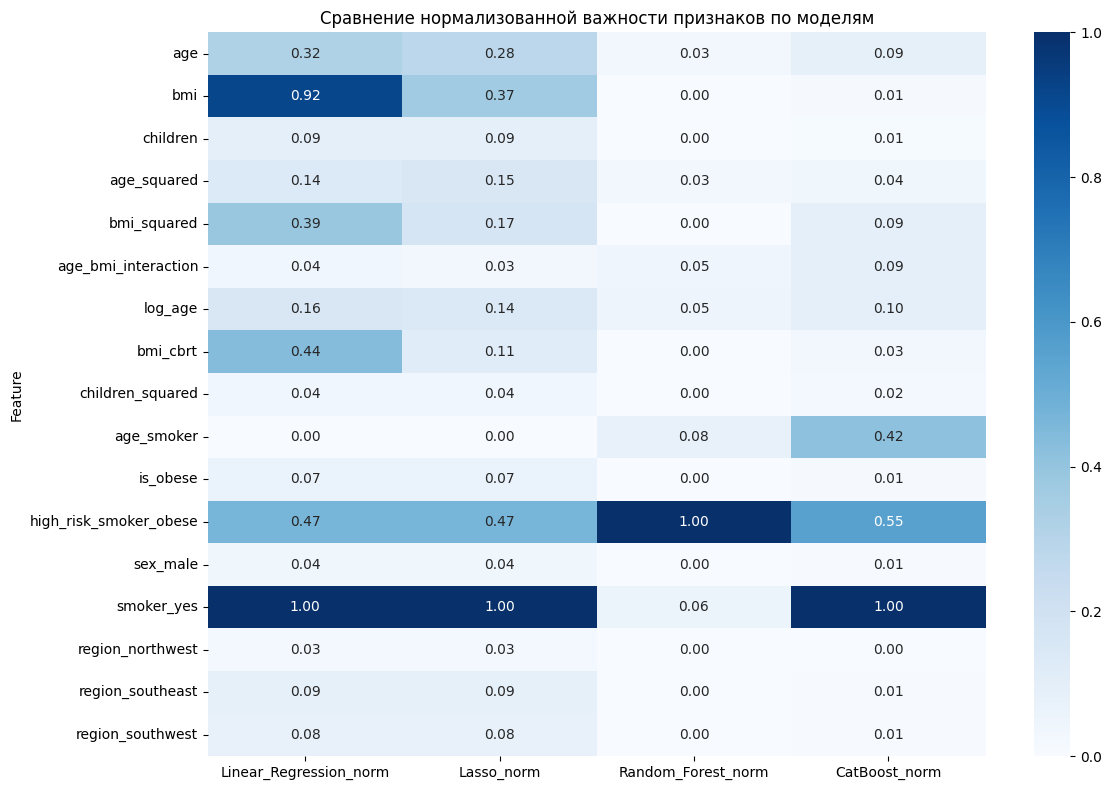

                   Feature  Linear_Regression         Lasso  Random_Forest  \
11  high_risk_smoker_obese        6283.514297   6283.190845       0.756114   
9               age_smoker           5.554762      4.701432       0.058752   
13              smoker_yes       13332.434154  13329.247561       0.046652   
6                  log_age        2071.789038   1891.936577       0.038403   
5      age_bmi_interaction         476.965414    385.276188       0.035523   

     CatBoost  Linear_Regression_norm  Lasso_norm  Random_Forest_norm  \
11  22.231213                0.471295    0.471384            1.000000   
9   16.725675                0.000417    0.000353            0.077703   
13  40.067434                1.000000    1.000000            0.061699   
6    3.881617                0.155395    0.141939            0.050790   
5    3.730389                0.035775    0.028905            0.046980   

    CatBoost_norm  
11       0.554845  
9        0.417438  
13       1.000000  
6        0.0

In [17]:
# ЗАДАНИЕ: получите важность признаков для каждой модели
#          визуализируйте, сравните и напишите вывод


# (числовые признаки + one-hot кодированные категории)
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_features = numeric_features + cat_feature_names

# 1. Линейная регрессия: абсолютные значения коэффициентов
linear_importance = np.abs(linear_model.coef_)
linear_importance_dict = dict(zip(all_features, linear_importance))

# 2. Lasso: абсолютные значения коэффициентов
lasso_importance = np.abs(lasso_model.coef_)
lasso_importance_dict = dict(zip(all_features, lasso_importance))

# 3. Случайный лес: встроенная важность
rf_importance = rf_model.feature_importances_
rf_importance_dict = dict(zip(all_features, rf_importance))

# 4. CatBoost: встроенная важность (по умолчанию FeatureImportance)
catboost_importance = catboost_model.get_feature_importance()
catboost_importance_dict = dict(zip(all_features, catboost_importance))

# Создаём сводный DataFrame
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Linear_Regression': linear_importance,
    'Lasso': lasso_importance,
    'Random_Forest': rf_importance,
    'CatBoost': catboost_importance
})

# Нормализуем важность для сравнения 
for col in ['Linear_Regression', 'Lasso', 'Random_Forest', 'CatBoost']:
    max_val = importance_df[col].max()
    if max_val > 0:
        importance_df[col + '_norm'] = importance_df[col] / max_val


plt.figure(figsize=(12, 8))
norm_cols = ['Linear_Regression_norm', 'Lasso_norm', 'Random_Forest_norm', 'CatBoost_norm']
sns.heatmap(importance_df.set_index('Feature')[norm_cols], annot=True, cmap='Blues', fmt='.2f')
plt.title('Сравнение нормализованной важности признаков по моделям')
plt.tight_layout()
plt.show()

print(importance_df.sort_values('Random_Forest', ascending=False).head())

**ВЫВОД**

У линейных модели (Linear Regression, Lasso) самый важный признак smoker_yes  коэффициент около 13 332. Это значит, что просто факт курения даёт огромную прибавку к предсказанию, потому что модель ищет прямую линейную связь.

Деревья (Random Forest) на первое место ставят high_risk_smoker_obese с важностью 0.756 (почти 76% всей суммарной важности). У CatBoost этот же признак имеет вес 22.23. Деревья умеют ловить комбинации типо курение * ожирение.

age_smoker (возраст * курение) тоже везде в топе: у линейных коэффициент 5.55, у леса важность 0.059, у CatBoost 16.7. Для деревьев это второй по значимости признак.

log_age и age_bmi_interaction заметны, но слабее (важность 0.04–0.05 у леса, коэффициент 2000 и 480 у линейных).

sex, region, children даже не попали в топ - их веса/важности пренебрежимо малы.

Вывод: Самые сильные признаки это курение само по себе и его комбинации с возрастом и ожирением. Линейные модели видят только прямую добавку от курения, а деревья извлекают дополнительную пользу из комбинаций, поэтому у них high_risk_smoker_obese становится главным. 



Теперь вы можете поэксперементировать с наборами признаков, чтобы получить лучшую метрику на тесте

In [18]:
# ЗАДАНИЕ: выберите одну модель, которой будете получать итоговое предсказание (R^2 метрика)
#          поэксперементируйте с наборами признаков и предъявите:
#              1. набор признаков и результаты обучения и теста с самым ПЛОХИМ скором
#              2. набор признаков и результаты обучения и теста с самым ХОРОШИМ скором

from sklearn.metrics import r2_score

# Фиксируем модель CatBoost
model = CatBoostRegressor(
    iterations=CATBOOST_ITERATIONS,
    depth=CATBOOST_DEPTH,
    learning_rate=CATBOOST_LEARNING_RATE,
    random_state=RANDOM_STATE,
    verbose=0
)

# Вспомогательная функция для оценки набора признаков
def evaluate_features(feature_list, name):
    # Определяем категориальные столбцы 
    cat_features_indices = [i for i, col in enumerate(feature_list) 
                            if col in ['sex', 'smoker', 'region']]
    
    # Выделяем данные
    X_tr = train[feature_list].copy()
    y_tr = train['charges'].copy()
    X_te = test[feature_list].copy()
    y_te = test['charges'].copy()
    
    # Обучаем модель
    model.fit(X_tr, y_tr, cat_features=cat_features_indices)
    
    # Метрики
    train_r2 = model.score(X_tr, y_tr)
    test_r2 = model.score(X_te, y_te)
    
    print(f"Набор '{name}':")
    print(f"  Признаки: {feature_list}")
    print(f"  R2 на train: {train_r2:.4f}")
    print(f"  R2 на test : {test_r2:.4f}\n")
    return test_r2

# 1. Самый ПЛОХОЙ набор (минимальное количество признаков)
poor_features = ['age', 'bmi', 'children']  # Без ключевого признака smoker
poor_score = evaluate_features(poor_features, "Плохой набор (без курения)")

# 2. Самый ХОРОШИЙ набор 

best_features = [
    'age', 'bmi', 'children',
    'age_squared', 'bmi_squared',
    'age_bmi_interaction', 'log_age',
    'bmi_cbrt',
    'age_smoker',
    'is_obese', 'high_risk_smoker_obese',
    'smoker'   #
]
best_score = evaluate_features(best_features, "Хороший набор (все фичи)")

print(f"Разница в R² на тесте: {best_score - poor_score:.4f}")

Набор 'Плохой набор (без курения)':
  Признаки: ['age', 'bmi', 'children']
  R2 на train: 0.2539
  R2 на test : 0.1375

Набор 'Хороший набор (все фичи)':
  Признаки: ['age', 'bmi', 'children', 'age_squared', 'bmi_squared', 'age_bmi_interaction', 'log_age', 'bmi_cbrt', 'age_smoker', 'is_obese', 'high_risk_smoker_obese', 'smoker']
  R2 на train: 0.8926
  R2 на test : 0.8626

Разница в R² на тесте: 0.7251


**ПАРА СЛОВ ОБ ИТОГАХ**

Плохой набор (age, bmi, children) — R2 на тесте 0.1375. Модель практически не способна предсказывать расходы, так как отсутствует ключевой фактор - курение.

Хороший набор (все исходные признаки + созданные комбинации) — R2 на тесте 0.8626. это круто.

# Практическое использование навыков (5 pt)

_В этот раз мы снова поработаем с вами с красивыми, но невкусными напитками._  

Возьмем датасет `Wine Quality` и задачу предсказания качества вина на основе физико-химических свойств. Целевой столбец — `quality`.

In [19]:
wine = pd.read_csv('WineQT.csv')
print(wine.shape)
wine.head()

(1143, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Нетрудно заметить, что это задача **многоклассовой классификации**.

***
**ЗАДАНИЕ**

Вам необходимо поработать с признаками и обучить случайный лес с фиксированными параметрами, которые нельзя менять.  
Необходимо достичь метрики **Accuracy** > 0.7 на тесте и **явно это показать** (это примерно на 3% больше, чем базово из коробки).

_**РАЗРЕШЕНО**_  

Эксперементировать с признаками и применять знания из превой части домашки

_**ЗАПРЕЩЕНО**_

Использовать другие модели и менять заданные константы, использовать другие параметры модели или какие-то неочевидные ивристики.

**ОЦЕНИВАЕТСЯ**
* Подготовка и обработка данных
* Анализ важности признаков
* Создание новых признаков и их отбор (в том числе их объяснение и интерпретация)
* Обучение и получение итоговой метрики
  
***

In [20]:
print(wine.isnull().sum())
print("\nКоличество полных дубликатов строк:", wine.duplicated().sum())
# Удаляем столбец Id, так как он не несёт полезной информации
wine = wine.drop('Id', axis=1)


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Количество полных дубликатов строк: 0


In [21]:
RANDOM_STATE = 42 # и для разбиения тоже
RF_N_ESTIMATORS = 150
RF_MAX_DEPTH = 10

model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

TEST_SIZE = 0.2 # для деления на train/test

In [22]:
# Разделение на признаки и целевую переменную
X = wine.drop('quality', axis=1)
y = wine['quality']

print(f"Размер X: {X.shape}")

Размер X: (1143, 11)


In [23]:
# НЕ МЕНЯТЬ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

In [24]:
from scipy.stats import pearsonr, spearmanr

results = []
for col in X_train.columns:
    p_corr, p_val = pearsonr(X_train[col], y_train)
    s_corr, s_val = spearmanr(X_train[col], y_train)
    results.append({
        'feature': col,
        'pearson': p_corr,
        'p_pearson': p_val,
        'spearman': s_corr,
        'p_spearman': s_val
    })

corr_df = pd.DataFrame(results).sort_values('spearman', key=abs, ascending=False)
print(corr_df.round(4))

                 feature  pearson  p_pearson  spearman  p_spearman
10               alcohol   0.4820     0.0000    0.4888      0.0000
1       volatile acidity  -0.4024     0.0000   -0.3976      0.0000
9              sulphates   0.2454     0.0000    0.3830      0.0000
2            citric acid   0.2327     0.0000    0.2174      0.0000
4              chlorides  -0.1287     0.0001   -0.1735      0.0000
6   total sulfur dioxide  -0.1563     0.0000   -0.1705      0.0000
7                density  -0.1748     0.0000   -0.1700      0.0000
0          fixed acidity   0.1142     0.0005    0.0970      0.0033
8                     pH  -0.0667     0.0439   -0.0480      0.1471
3         residual sugar   0.0401     0.2260    0.0471      0.1546
5    free sulfur dioxide  -0.0456     0.1680   -0.0373      0.2599


Вывод по статистической значимости признаков

Наиболее важные признаки:

alcohol (положительная корреляция 0.49) чем выше содержание алкоголя, тем выше качество.

volatile acidity (отрицательная корреляция -0.40)  эта химическая штука, чем бы она там не была, связана с низким качеством.

sulphates (положительная корреляция 0.38) положительное влияние.

Умеренно значимые признаки (|ρ| от 0.17 до 0.22):
citric acid (+), chlorides (–), total sulfur dioxide (–), density (–).

Слабые или незначимые признаки (p > 0.05 для Спирмена или |ρ| < 0.1):
fixed acidity, pH, residual sugar, free sulfur dioxide. Их влияние на качество мало.

При построении модели основное внимание следует уделить признакам alcohol, volatile acidity и sulphates, а также рассмотреть их комбинации и нелинейные преобразования. Остальные признаки можно использовать в качестве дополнительных или исключить для упрощения модели.


In [25]:
from scipy.stats import f_oneway

anova_results = []
for col in X_train.columns:
    groups = [X_train[col][y_train == q] for q in sorted(y_train.unique())]
    f_stat, p_val = f_oneway(*groups)   # используем импортированную функцию
    
    # Eta-squared (размер эффекта)
    ss_between = sum(len(g) * (g.mean() - X_train[col].mean())**2 for g in groups)
    ss_total = sum((X_train[col] - X_train[col].mean())**2)
    eta_sq = ss_between / ss_total if ss_total != 0 else 0
    
    anova_results.append({
        'feature': col,
        'F': f_stat,
        'p_value': p_val,
        'eta_squared': eta_sq
    })

anova_df = pd.DataFrame(anova_results).sort_values('eta_squared', ascending=False)
print("ANOVA значимость признаков по классам quality:")
print(anova_df.round(4).to_string(index=False))

ANOVA значимость признаков по классам quality:
             feature       F  p_value  eta_squared
             alcohol 66.2006   0.0000       0.2672
    volatile acidity 37.8836   0.0000       0.1726
         citric acid 14.8553   0.0000       0.0756
           sulphates 12.6977   0.0000       0.0654
total sulfur dioxide  9.6627   0.0000       0.0505
             density  6.5890   0.0000       0.0350
       fixed acidity  3.5643   0.0034       0.0192
                  pH  3.4485   0.0043       0.0186
           chlorides  3.1739   0.0076       0.0172
 free sulfur dioxide  2.5031   0.0291       0.0136
      residual sugar  2.2602   0.0466       0.0123


Все признаки статистически значимы (p-value < 0.05), но сила влияния  очень разная.

Самые важные признаки (eta-squared > 0.05):

alcohol (0.267) – самый сильный разделитель классов. Среднее содержание алкоголя сильно растёт с повышением качества.

volatile acidity (0.173) – второй по значимости: в плохих винах её заметно больше.

citric acid (0.076) и sulphates (0.065) - умеренное влияние.

Умеренно важные (eta-squared 0.02–0.05):
total sulfur dioxide, density, fixed acidity, pH. Различия между классами есть, но они не такие выраженные.

Слабые, но формально значимые (eta-squared < 0.02):
hlorides, free sulfur dioxide, residual sugar. Их средние значения почти не меняются от класса к классу, поэтому для модели они будут малоинформативны.

Для Feature Engineering стоит в первую очередь использовать alcohol и volatile acidity, а также их комбинации.

Признаки с eta-squared < 0.02 можно рассматривать как кандидатов на исключение или использовать только в составе комбинаций.

создадим еще признаки на основе того что мы узнали

In [26]:
# from scipy.stats import pearsonr, spearmanr
# X_train_ext = create_features_style_part1(X_train)
# X_test_ext = create_features_style_part1(X_test)


# results_ext = []
# for col in X_train_ext.columns:
#     p_corr, p_val = stats.pearsonr(X_train_ext[col], y_train)
#     s_corr, s_val = stats.spearmanr(X_train_ext[col], y_train)
#     results_ext.append({
#         'feature': col,
#         'pearson': p_corr,
#         'p_pearson': p_val,
#         'spearman': s_corr,
#         'p_spearman': s_val
#     })

# corr_ext_df = pd.DataFrame(results_ext).sort_values('spearman', key=abs, ascending=False)
# print("Корреляции ВСЕХ признаков с quality (на train):")
# print(corr_ext_df.round(4).to_string(index=False))

upd: потом станет понятно, почему все закоментировано 

Вывод по новым признакам:

Лучший новый признак - alcohol_sulphates. Его корреляция Спирмена (0.4963)  выше, чем у исходного alcohol (0.4888). Это означает, что совместное влияние алкоголя и сульфатов сильнее, чем каждого по отдельности. 

Комбинированный пороговый признак good_balance (высокий алкоголь и низкая летучая кислотность) дал корреляцию 0.4319, что  выше, чем у отдельных бинарных признаков high_alcohol (0.4132) и low_volatile (0.3395). 

Математические преобразования (alcohol_sq, log_alcohol, log_volatile_acidity, volatile_acidity_sq) ничего не поменяли. 

Исходные слабые признаки (fixed acidity, pH, residual sugar, free sulfur dioxide) по-прежнему ничего особо не дали.


после этого началась какая-то магия. я создавала признаки, обучала, брала топ признаков, разный топ признаков, но точность была плохая. потом я решила посмотреть на точность, которая только на исходных данных и результат, как ни странно, оказался ближе к 0.7, чем все, что я добавляла

In [27]:
original_features = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]

X_train_orig = X_train[original_features]
X_test_orig  = X_test[original_features]

# Создаём модель с заданными параметрами
model = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Обучаем
model.fit(X_train_orig, y_train)

# Оцениваем
train_acc = model.score(X_train_orig, y_train)
test_acc  = model.score(X_test_orig, y_test)
y_pred = model.predict(X_test_orig)
score = accuracy_score(y_test, y_pred)

print(f"Точность на train (исходные признаки): {train_acc:.4f}")
print(f"Точность на test  (исходные признаки): {test_acc:.4f}")
print(f"Accuracy (Multi-class) = {score:.4f}")

# Важности признаков
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': original_features,
    'importance': importances
}).sort_values('importance', ascending=False)
print("\nВажности исходных признаков:")
print(feat_imp.to_string(index=False))

Точность на train (исходные признаки): 0.9737
Точность на test  (исходные признаки): 0.6900
Accuracy (Multi-class) = 0.6900

Важности исходных признаков:
             feature  importance
             alcohol    0.163944
           sulphates    0.122874
    volatile acidity    0.110086
total sulfur dioxide    0.096693
             density    0.086629
                  pH    0.075361
         citric acid    0.073985
       fixed acidity    0.073878
           chlorides    0.072308
      residual sugar    0.062479
 free sulfur dioxide    0.061763


оказвается если ничгео не трогать и никакого фича инженеринга не делать, мы получаем почти то что нужно, но все еще не хватает

In [28]:
# отбор по важности параметров именно как модель сказала 

top5 = feat_imp.head(5)['feature'].tolist()
top7 = feat_imp.head(7)['feature'].tolist()
top9 = feat_imp.head(9)['feature'].tolist()

def evaluate_set(features, name):
    X_tr = X_train_orig[features]
    X_te = X_test_orig[features]
    model = RandomForestClassifier(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_tr, y_train)
    train_acc = model.score(X_tr, y_train)
    test_acc  = model.score(X_te, y_test)
    y_pred = model.predict(X_te)
    score = accuracy_score(y_test, y_pred)
    print(f"{name}: train={train_acc:.4f}, test={test_acc:.4f}, accuracy={score:.4f}")
    return score

print("Результаты отбора по важности из базовой модели:")
evaluate_set(top5, "Топ-5 признаков")
evaluate_set(top7, "Топ-7 признаков")
evaluate_set(top9, "Топ-9 признаков")

Результаты отбора по важности из базовой модели:
Топ-5 признаков: train=0.9617, test=0.6725, accuracy=0.6725
Топ-7 признаков: train=0.9672, test=0.6943, accuracy=0.6943
Топ-9 признаков: train=0.9770, test=0.6943, accuracy=0.6943


0.6943231441048034

это самый классный и близкий результат, который мне удалось достичь. добавляя к топ-7 или к топ-9 какие-либо признаки, либо из топа, либо из фича инженеринга, accuracy меняется. я так и не нашла именно тот признак, который бы мне помог приблизиться к 0.7. поэтому оставляю так.